In [4]:
### The following code was used for DQN and DDQN for the base environment ###

In [5]:
#IMPORTS
import gymnasium as gym
import ale_py

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm
from collections import deque


In [2]:
device = torch.device('cuda' if torch.cuda.is_available()else 'cpu')

In [3]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128,128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [6]:
class DQNAGENT():

  def __init__(self,game,target_update_freq,memory,learning_rate,batch,mode):

    self.game = game
    self.target_update = target_update_freq
    self.memorysize = memory
    self.batch_size = batch
    self.learning_rate = learning_rate
    self.mode = mode
    
    self.env = gym.make(game)
    self.state_space = self.env.observation_space.shape[0]
    self.num_actions = self.env.action_space.n
    
    self.memory = deque(maxlen = memory)
    self.epsilon = 1
    self.epsilon_min = 0.001
    self.epsilon_decay = 0.992
    
    self.q1 = DQN(self.state_space,self.num_actions).to(device)
    self.q2 = DQN(self.state_space,self.num_actions).to(device)
    self.q2.load_state_dict(self.q1.state_dict())
    self.q1.train()
    self.q2.eval()
    self.optimizer = optim.Adam(self.q1.parameters(), lr=self.learning_rate)

    self.counter = 0
    self.episode = 0
    self.reward_episode = []

    self.xposition = []
    self.yposition = []


  def greedypolicy(self,state):

    if np.random.rand() <= self.epsilon:

        return np.random.randint(self.num_actions)
    else:
    
        with torch.no_grad():

         q_values = self.q1(state)
         move = torch.argmax(q_values).item()

        return move

  def experiencereplay(self):
    if len(self.memory) < self.batch_size:
        return

    batch = random.sample(self.memory, self.batch_size)
    state_batch, action_batch, reward_batch, next_state_batch, terminal_batch = zip(*batch)

    state_batch = torch.cat(state_batch,dim = 0).to(device)
    action_batch = torch.LongTensor(action_batch).unsqueeze(1).to(device)
    reward_batch = torch.FloatTensor(reward_batch).to(device)
    next_state_batch = torch.cat(next_state_batch).to(device)
    terminal_batch = torch.FloatTensor(terminal_batch).to(device)


    yvals = self.q1(state_batch).gather(1, action_batch).squeeze()

    # Compute target Q-values using the target network
    with torch.no_grad():

        if self.mode == 'DQN':

          target_values = self.q2(next_state_batch).max(1)[0]

        elif self.mode == 'DDQN':

          target_states = self.q2(next_state_batch)

          next_action = torch.argmax(self.q1(next_state_batch), dim=1)
          target_values = target_states.gather(1, next_action.unsqueeze(1)).squeeze(1)
          
        yhatvals = reward_batch + 0.99 * target_values * (1- terminal_batch)


    loss = F.mse_loss(yvals, yhatvals)
    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

  def train(self,episode_num):

     for i in tqdm(range(0,episode_num)):

       done = False
       reward_total = 0
    
       current_state,info = self.env.reset()
       current_state_torch = torch.from_numpy(current_state).float().unsqueeze(0).to(device)
       self.xposition.append(current_state[0])
       self.yposition.append(current_state[1])
      
       while done == False:
        
        action = self.greedypolicy(current_state_torch)
        next_state, reward, terminated, truncated, info = self.env.step(action)
        self.xposition.append(next_state[0])
        self.yposition.append(next_state[1])

        
        done = terminated or truncated
        next_state_torch = torch.from_numpy(next_state).float().unsqueeze(0).to(device)

        self.memory.append((current_state_torch, action, reward, next_state_torch, done))
        self.experiencereplay()

        current_state_torch = next_state_torch
        reward_total += reward
        self.counter +=1

       self.episode += 1
       self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
       self.reward_episode.append(reward_total)


       if self.episode % self.target_update == 0:
            self.q2.load_state_dict(self.q1.state_dict())
              
       print(i,reward_total)


  def reward_plot(self,window,reward_episode):
    moving_average = []
    for i in range(1,window):

      moving_average.append(np.mean(reward_episode[:i]))

    for i in range(window,len(reward_episode)+1):
       average_window = reward_episode[i-window:i]
       moving_average.append(np.mean(average_window))
    
    self.moving_average = moving_average

    plt.plot(np.linspace(0,len(reward_episode)-1,len(reward_episode)),reward_episode, alpha = 0.6,label='Episodic Reward', color = 'blue')
    plt.plot(np.linspace(0,len(reward_episode)-1,len(reward_episode)),np.array(moving_average), label = 'Rolling Average',color = 'orange')
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
    plt.rcParams['axes.facecolor'] = 'lavender'
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title(str(self.game) + "-" +str(self.mode))
    plt.legend()
    plt.show()

  def multi_agent(self,number_agents,number_train):
    rewards = np.zeros(number_train)
    for i in range(0,number_agents):
     self.train(number_train)
     rewards += np.array(self.reward_episode)
     self.__init__(self.game, self.target_update,self.memorysize,self.learning_rate,self.batch_size,self.mode)
    
    self.multiagent_reward = list(rewards/number_agents)

  
  def save_position(self):
    torch.save({'xposition':self.xposition}, "xposition2/xpo_" + str(self.episode) +".npy")
    torch.save({'yposition':self.yposition}, "yposition2/ypo_" + str(self.episode)+ ".npy")




In [ ]:
### Training a DQN agent ###

#This is all for the base environment w
#Initialise agent using following structure DQNAGENT(environment,memory buffer size, learning rate,batchsize,version of DQN)

#Example for DQN
  #agent1 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DQN') # These parameters were used for the results
  #agent1.train(1500) trains agent for 1500 episodes
  #agent1.reward_plot(100,agent1.reward_episode) #plots the agents result with its moving average
  #agent1.moving_average gives the moving average as a list



#Example for DDQN
  #agent1 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DDQN') for final argument use 'DDQN
  #agent1.train(1500) trains agent for 1500 episodes
  #agent1.reward_plot(100,agent1.reward_episode) plots the agents result with its moving average
  #agent1.moving_average gives the moving average as a list 

In [11]:
agent1 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DQN')
agent1.train(1500)

  0%|          | 0/1500 [00:00<?, ?it/s]

0 -116.29421649724358
1 -342.99912057880175
2 -23.979635490544652
3 -30.072633465135937
4 -142.56206532103414
5 -437.6775620469601
6 -164.5721581518556
7 -107.5448191095039
8 -104.55190186061257
9 -91.42819455151401
10 -86.21609827958801
11 -93.7574292206874
12 -102.30607701860053
13 -371.0502616108047
14 -177.03996703497586
15 -105.71803303132756
16 -138.52894778637162
17 -213.76408395150622
18 -80.12049505374394
19 -142.63332934488008
20 -135.6408436029394
21 -217.68935707052495
22 -148.25641326576843
23 -86.49765587156182
24 -203.6090261731241
25 -354.33639333931
26 -52.08735131584908
27 -119.63862725967205
28 -216.83110760132342
29 -105.80477692667267
30 -75.95224623655862
31 -160.0974811384058
32 -162.72771712466331
33 -104.53759126368402
34 -159.3840092467636
35 -91.81159823303443
36 -113.88344890909161
37 -119.01807031003919
38 -165.0917343156398
39 -238.48766277248632
40 -116.17174135299335
41 -37.42414982197897
42 -82.4954280083374
43 -83.81617786264326
44 -194.99090566755748


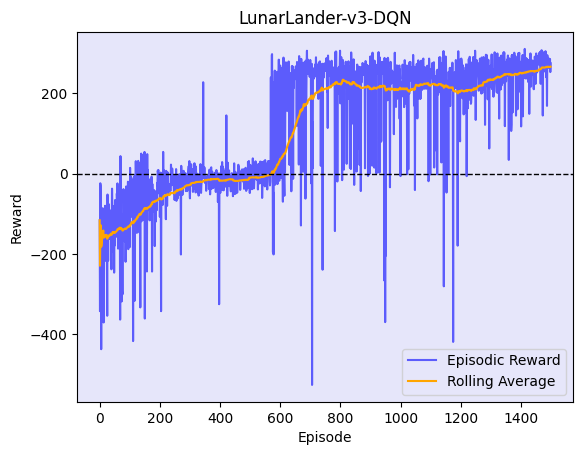

In [12]:
agent1.reward_plot(100,agent1.reward_episode)

In [13]:
agent1 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DDQN')
agent1.train(1500)

  0%|          | 0/1500 [00:00<?, ?it/s]

0 -190.7712299777597
1 -321.50210324502984
2 -77.85228326949763
3 -105.68071719902579
4 -98.0809782862731
5 -121.40168431092519
6 -140.79592601515208
7 -120.6050670918149
8 -84.42885234290965
9 8.911897870675077
10 -80.30349359052141
11 -66.05305747835949
12 -447.62982197889283
13 -131.88191318960338
14 -101.20212981723883
15 -67.0269771628796
16 -106.2884878457226
17 -264.94043816380383
18 -87.8271088564106
19 -269.1008424757325
20 -467.6079499851978
21 -58.83606672018152
22 -117.48267196837446
23 -200.27166683206352
24 -167.54225995123716
25 -157.73944380745775
26 -234.1333054441481
27 -104.75767148325394
28 -130.62978392666372
29 -76.21914487006615
30 -236.81868704249007
31 -108.05180756869197
32 -252.51316159395265
33 -190.53815708169608
34 -153.15950071233493
35 -159.56284582891948
36 -65.28692304906569
37 -199.186658298087
38 -74.37531641876082
39 -191.8403322424403
40 -69.22247127590614
41 -359.14334321854005
42 -191.33026873739612
43 -244.1260271765059
44 -94.00434959030709
45 

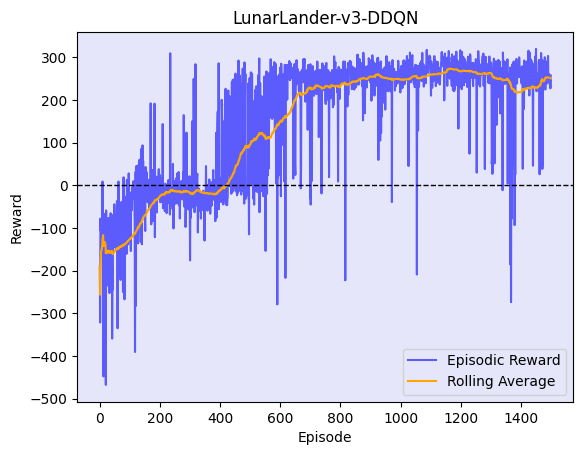

In [14]:
agent1.reward_plot(100,agent1.reward_episode)